Saved: bwb_airflow_faithful.gif


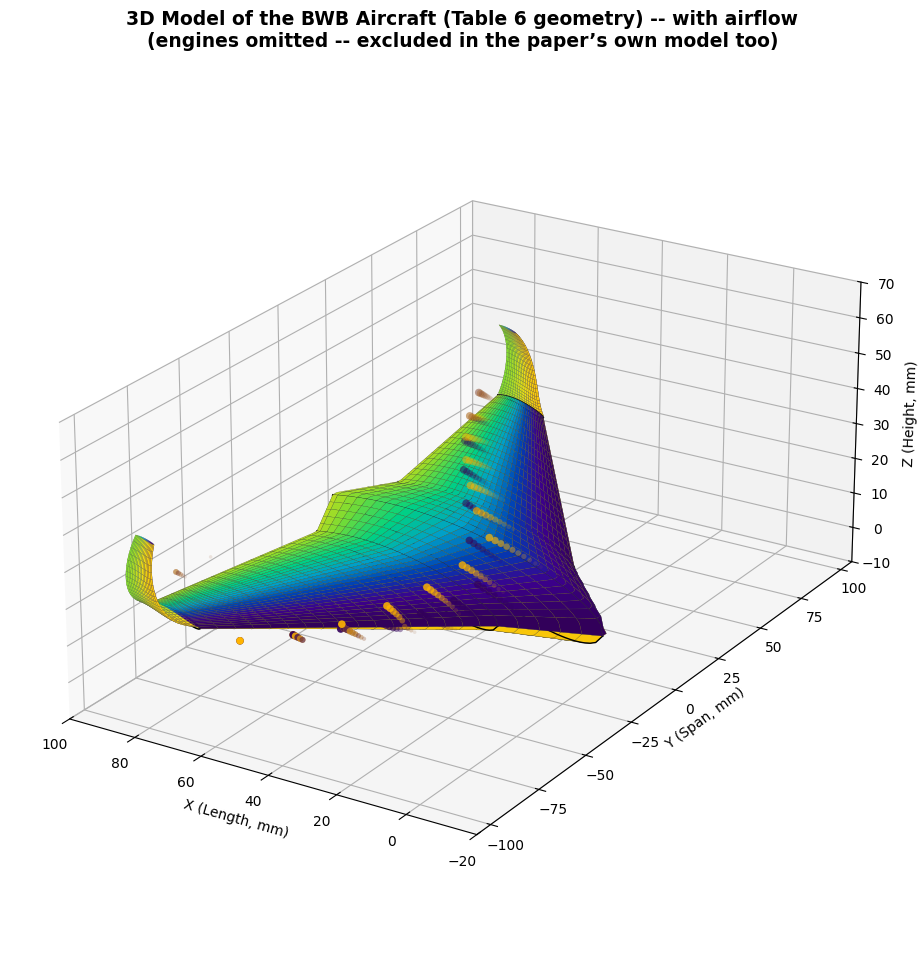

In [1]:
"""
bwb_airflow_faithful.py
--------------------------
Same as before (verified Table 6 geometry, animated airflow), with two
fixes applied per request:
  1. The winglet is now the smooth, bent, Cp-colour-blended surface
     (same style used in later scripts) instead of a flat single-colour
     triangular panel.
  2. The blue lift-arrow (quiver) has been removed.

Run:
    python3 bwb_airflow_faithful.py

Produces:
    bwb_airflow_faithful.gif
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.animation import FuncAnimation, PillowWriter

# =============================================================================
# 0. SAME CUSTOM COLORSCALE AS THE CONVENTIONAL PLANE (for fair comparison)
# =============================================================================
_stops = [0.00, 0.15, 0.30, 0.45, 0.60, 0.75, 0.88, 1.00]
_colors = ['rgb(50,0,90)', 'rgb(60,0,140)', 'rgb(0,60,180)', 'rgb(0,160,200)',
           'rgb(0,210,130)', 'rgb(120,220,50)', 'rgb(240,220,20)',
           'rgb(255,180,0)']


def _rgb_str_to_tuple(s):
    nums = s[s.index('(') + 1:s.index(')')].split(',')
    return tuple(int(n) / 255 for n in nums)


_cdict_colors = [_rgb_str_to_tuple(c) for c in _colors]
CMAP = mcolors.LinearSegmentedColormap.from_list(
    'user_scale', list(zip(_stops, _cdict_colors)))
CP_MIN, CP_MAX = -1.2, 0.6
NORM = mcolors.Normalize(vmin=CP_MIN, vmax=CP_MAX)
WARM = np.array(_cdict_colors[-1])
COOL = np.array(_cdict_colors[0])

# =============================================================================
# 1. VERIFIED TABLE 6 GEOMETRY
# =============================================================================
INNER_SWEEP_DEG, INNER_ROOT_CHORD, INNER_TIP_CHORD, INNER_SPAN = 45.0, 86.0, 56.0, 22.0
OUTER_SWEEP_DEG, OUTER_ROOT_CHORD, OUTER_TIP_CHORD, OUTER_SPAN = 35.0, 56.0, 15.0, 70.0
HALF_SPAN = INNER_SPAN + OUTER_SPAN


def local_chord(y):
    ay = np.abs(y)
    inner = INNER_ROOT_CHORD - (INNER_ROOT_CHORD - INNER_TIP_CHORD) * \
        np.clip(ay / INNER_SPAN, 0, 1)
    outer = OUTER_ROOT_CHORD - (OUTER_ROOT_CHORD - OUTER_TIP_CHORD) * \
        np.clip((ay - INNER_SPAN) / OUTER_SPAN, 0, 1)
    return np.where(ay <= INNER_SPAN, inner, outer)


def leading_edge_x(y):
    ay = np.abs(y)
    le_root_outer = INNER_SPAN * np.tan(np.radians(INNER_SWEEP_DEG))
    inner_le = ay * np.tan(np.radians(INNER_SWEEP_DEG))
    outer_le = le_root_outer + (ay - INNER_SPAN) * np.tan(np.radians(OUTER_SWEEP_DEG))
    return np.where(ay <= INNER_SPAN, inner_le, outer_le)


def thickness_ratio(y):
    frac = np.clip(np.abs(y) / HALF_SPAN, 0, 1)
    return 0.18 * (1 - frac) + 0.10 * frac


def camber_strength(y):
    frac = np.clip(np.abs(y) / HALF_SPAN, 0, 1)
    return 0.042 * (1 - frac) + 0.058 * frac


def naca_thickness(xc, t):
    return 5 * t * (0.2969 * np.sqrt(xc) - 0.1260 * xc
                     - 0.3516 * xc ** 2 + 0.2843 * xc ** 3
                     - 0.1015 * xc ** 4)


def camber_supercritical(xc, k):
    return k * (xc ** 1.6) * (1 - xc) * 5.2


def cp_upper(xc):
    return -1.2 + 1.5 * xc


def cp_lower(xc):
    return 0.5 - 0.35 * xc


n_span, n_chord = 90, 60
y_vals = np.linspace(-HALF_SPAN, HALF_SPAN, n_span)
xc_vals = np.linspace(0, 1, n_chord)
XC, Y = np.meshgrid(xc_vals, y_vals)
chord = local_chord(Y)
x_le = leading_edge_x(Y)
X = x_le + XC * chord
t_ratio = thickness_ratio(Y)
k_cam = camber_strength(Y)
half_t = naca_thickness(XC, t_ratio) * chord
camber = camber_supercritical(XC, k_cam) * chord
Z_upper_raw = camber + half_t
Z_lower_raw = camber - half_t
colors_upper = CMAP(NORM(cp_upper(XC)))
colors_lower = CMAP(NORM(cp_lower(XC)))

PITCH_DEG = -14
pr = np.radians(PITCH_DEG)


def pitch_rotate(Xp, Zp):
    Xr = Xp * np.cos(pr) + Zp * np.sin(pr)
    Zr = -Xp * np.sin(pr) + Zp * np.cos(pr)
    return Xr, Zr


X_u, Z_upper = pitch_rotate(X, Z_upper_raw)
X_l, Z_lower = pitch_rotate(X, Z_lower_raw)

# =============================================================================
# 2. WINGLET -- FIXED: smooth, bent, Cp-colour-blended surface (was a
# flat single-colour triangular panel before)
# =============================================================================
def build_winglet_surface(sign):
    c0 = local_chord(HALF_SPAN)
    t_param = np.linspace(0, 1, 22)
    xc_wl = np.linspace(0, 1, 18)
    Tp, XCw = np.meshgrid(t_param, xc_wl, indexing='ij')

    WL_SPAN = 18.0
    WL_ROOT_FRAC = 1.0
    WL_TIP_FRAC = 0.38
    WL_BEND_DEG = 78.0

    chord_wl = c0 * (WL_ROOT_FRAC * (1 - Tp) + WL_TIP_FRAC * Tp)
    theta = np.radians(WL_BEND_DEG) * (Tp ** 1.4)

    le0 = leading_edge_x(HALF_SPAN)
    sweep_wl = np.radians(OUTER_SWEEP_DEG + 6)
    le_x = le0 + Tp * WL_SPAN * np.tan(sweep_wl)
    Xw = le_x + XCw * chord_wl

    y_flat = HALF_SPAN + Tp * WL_SPAN * np.cos(theta)
    Yw = sign * y_flat

    base_z0 = camber_supercritical(0.3, camber_strength(HALF_SPAN)) * c0
    z_bend = Tp * WL_SPAN * np.sin(theta)
    half_t_wl = naca_thickness(XCw, 0.09) * chord_wl
    cam_wl = camber_supercritical(XCw, camber_strength(HALF_SPAN) *
                                     (1 - 0.4 * Tp)) * chord_wl

    Zw_upper = base_z0 + z_bend + cam_wl + half_t_wl
    Zw_lower = base_z0 + z_bend + cam_wl - half_t_wl
    Xw_u, Zw_upper = pitch_rotate(Xw, Zw_upper)
    Xw_l, Zw_lower = pitch_rotate(Xw, Zw_lower)

    colors_wl_upper = CMAP(NORM(cp_upper(XCw)))
    colors_wl_lower = CMAP(NORM(cp_lower(XCw)))
    return (Xw_u, Yw, Zw_upper, colors_wl_upper,
            Xw_l, Yw, Zw_lower, colors_wl_lower)


# =============================================================================
# 3. FIGURE
# =============================================================================
fig = plt.figure(figsize=(12.5, 9.8))
ax = fig.add_subplot(111, projection='3d')
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

ax.plot_surface(X_u, Y, Z_upper, facecolors=colors_upper, linewidth=0.15,
                  edgecolor='0.25', antialiased=True, shade=False, zorder=2)
ax.plot_surface(X_l, Y, Z_lower, facecolors=colors_lower, linewidth=0.15,
                  edgecolor='0.25', antialiased=True, shade=False, zorder=2)

for y_station in [-HALF_SPAN, -INNER_SPAN, 0, INNER_SPAN, HALF_SPAN]:
    idx = np.argmin(np.abs(y_vals - y_station))
    ax.plot(X_u[idx, :], Y[idx, :], Z_upper[idx, :], color='black',
             linewidth=1.0, zorder=5)
    ax.plot(X_l[idx, :], Y[idx, :], Z_lower[idx, :], color='black',
             linewidth=1.0, zorder=5)
for xc_station in [0.15, 0.4, 0.7]:
    idx = np.argmin(np.abs(xc_vals - xc_station))
    ax.plot(X_u[:, idx], Y[:, idx], Z_upper[:, idx], color='black',
             linewidth=0.6, alpha=0.5, zorder=5)

for sign in (1, -1):
    Xw_u, Yw_u, Zw_up, cw_up, Xw_l, Yw_l, Zw_lo, cw_lo = \
        build_winglet_surface(sign)
    ax.plot_surface(Xw_u, Yw_u, Zw_up, facecolors=cw_up, linewidth=0.1,
                      edgecolor='0.3', antialiased=True, shade=False,
                      zorder=6)
    ax.plot_surface(Xw_l, Yw_l, Zw_lo, facecolors=cw_lo, linewidth=0.1,
                      edgecolor='0.3', antialiased=True, shade=False,
                      zorder=6)

# NOTE: blue lift-arrow removed per request (was ax.quiver(...) here)

ax.set_xlim(-20, 100)
ax.set_ylim(-HALF_SPAN - 15, HALF_SPAN + 15)
ax.set_zlim(-10, 70)
ax.set_box_aspect((12, 19, 8))
ax.set_xlabel('X (Length, mm)')
ax.set_ylabel('Y (Span, mm)')
ax.set_zlabel('Z (Height, mm)')
ax.set_title('3D Model of the BWB Aircraft (Table 6 geometry) -- with airflow\n'
              '(engines omitted -- excluded in the paper\u2019s own model too)',
              fontsize=13.5, weight='bold')
ax.view_init(elev=23, azim=-58)
ax.invert_xaxis()

# =============================================================================
# 4. ANIMATED AIRFLOW -- dense, whole-span coverage
# =============================================================================
scat = ax.scatter([0], [0], [0], s=[10], zorder=10, linewidth=0)

trail_len = 11
trail_alpha = np.linspace(1.0, 0.0, trail_len) ** 1.1
trail_size = np.linspace(30, 4, trail_len)


def flow_path(ys, side, frac):
    c = local_chord(ys)
    le = leading_edge_x(ys)
    te = le + c
    margin = 7
    xp = (le - margin) + frac * (c + 2 * margin)
    xcl = np.clip((xp - le) / c, 0, 1)
    on = (xp >= le) & (xp <= te)
    t = thickness_ratio(ys)
    k = camber_strength(ys)
    cam = camber_supercritical(xcl, k) * c
    ht = naca_thickness(xcl, t) * c
    z = np.where(on, cam + side * ht, 0.0)
    xr, zr = pitch_rotate(xp, z)
    return xr, zr


flow_stations = np.linspace(-HALF_SPAN + 4, HALF_SPAN - 4, 13)


def update(frame):
    xs, ys_, zs, cs, ss = [], [], [], [], []
    n_stations = len(flow_stations)
    for si, ys in enumerate(flow_stations):
        station_phase = si / n_stations
        for side, color, spd in [(1, WARM, 0.021), (-1, COOL, 0.0085)]:
            lead = (station_phase + spd * frame) % 1.0
            for t in range(trail_len):
                f = (lead - t * 0.018) % 1.0
                xr, zr = flow_path(ys, side, f)
                xs.append(xr); ys_.append(ys); zs.append(zr)
                cs.append([*color, trail_alpha[t]])
                ss.append(trail_size[t])
    scat._offsets3d = (np.array(xs), np.array(ys_), np.array(zs))
    scat.set_facecolor(np.array(cs))
    scat.set_sizes(np.array(ss))
    return (scat,)


anim = FuncAnimation(fig, update, frames=50, interval=70, blit=False)
plt.tight_layout()
anim.save('bwb_airflow_faithful.gif', writer=PillowWriter(fps=14))
print("Saved: bwb_airflow_faithful.gif")

=== Enter MODIFIED model parameters ===
(these are exactly the parameters that change CL, L/D, and AR below -- press Enter to keep each default)



Inner (centerbody) camber strength [default 0.042]:  0.040
Outer (wing) camber strength [default 0.058]:  0.055
Inner span (mm) [default 22.0]:  21
Outer span (mm) [default 70.0]:  68
Inner root chord (mm) [default 86.0]:  84
Inner tip chord (mm) [default 56.0]:  54
Outer root chord (mm) [default 56.0]:  55
Outer tip chord (mm) [default 15.0]:  12


=== Computed live from GEOMS (edit GEOMS/constants above to change) ===
Modified: CL=0.275  L/D=13.3  AR=4.25  alpha_L0=-3.69deg  (paper ref: CL=0.667, L/D=35.1 [Table 20, alpha=0])
Saved: bwb_parametric_cl_ld.png


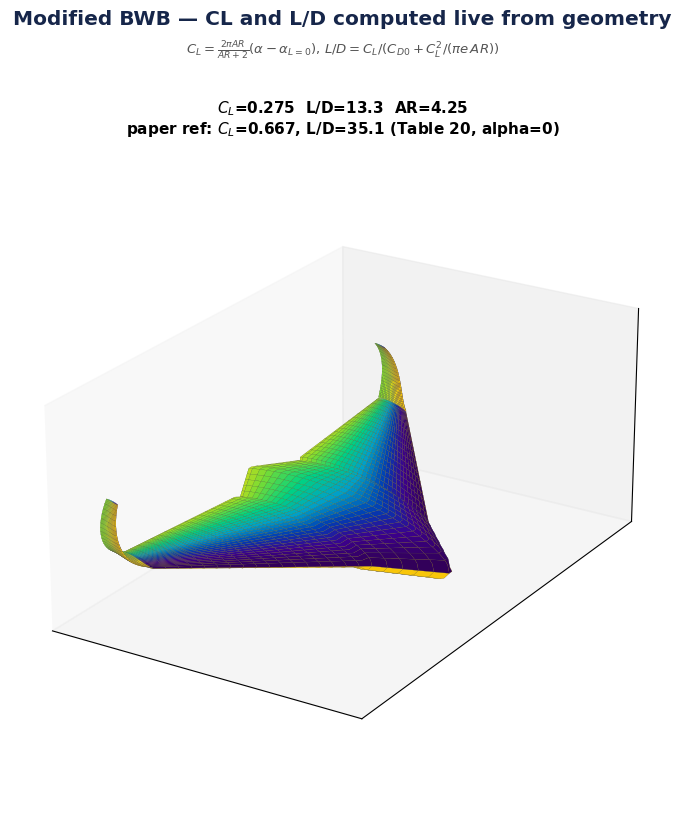

In [2]:
"""
bwb_parametric_cl_ld.py
---------------------------
Baseline panel REMOVED per request -- this now shows only the
Modified BWB, computed live from GEOMS['modified'].

CL, L/D, AR, the title text -- all still derived live from the
GEOMS dictionary below via the same closed-form equations:

    alpha_L0  = f(camber)
    AR        = (2*half_span)^2 / (2*S)
    CL        = (2*pi*AR/(AR+2)) * (alpha - alpha_L0)
    CD_i      = CL^2 / (pi * e * AR)
    CD        = CD0 + CD_i
    L/D       = CL / CD

WHAT TO EDIT: only the `GEOMS['modified']` dictionary and the four
CONSTANTS just below it.

HONEST NOTE: this closed-form estimate is a first-order approximation
-- it will NOT exactly reproduce the paper's real FLUENT-computed
number (shown alongside as a reference). For a body this thick and
blended, only full CFD gives a trustworthy final number.

Run:
    python3 bwb_parametric_cl_ld.py

Produces:
    bwb_parametric_cl_ld.png
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# =============================================================================
# USER INPUT -- ONLY parameters that actually feed into CL / L-D / AR below.
# =============================================================================
def ask(prompt, default):
    raw = input(f"{prompt} [default {default}]: ").strip()
    return float(raw) if raw else default


print("=== Enter MODIFIED model parameters ===")
print("(these are exactly the parameters that change CL, L/D, and AR "
      "below -- press Enter to keep each default)\n")

MOD_INNER_CAMBER = ask("Inner (centerbody) camber strength", 0.042)
MOD_OUTER_CAMBER = ask("Outer (wing) camber strength", 0.058)
MOD_INNER_SPAN = ask("Inner span (mm)", 22.0)
MOD_OUTER_SPAN = ask("Outer span (mm)", 70.0)
MOD_INNER_ROOT = ask("Inner root chord (mm)", 86.0)
MOD_INNER_TIP = ask("Inner tip chord (mm)", 56.0)
MOD_OUTER_ROOT = ask("Outer root chord (mm)", 56.0)
MOD_OUTER_TIP = ask("Outer tip chord (mm)", 15.0)

# =============================================================================
# THE GEOMETRY -- only 'modified' now (baseline removed)
# =============================================================================
GEOMS = {
    'modified': dict(
        inner_sweep=45.0, inner_root=MOD_INNER_ROOT, inner_tip=MOD_INNER_TIP,
        inner_span=MOD_INNER_SPAN,
        outer_sweep=35.0, outer_root=MOD_OUTER_ROOT, outer_tip=MOD_OUTER_TIP,
        outer_span=MOD_OUTER_SPAN,
        inner_thick=0.18, inner_camber=MOD_INNER_CAMBER,
        outer_thick=0.10, outer_camber=MOD_OUTER_CAMBER,
    ),
}

ALPHA_DEG = 0.0
SPAN_EFFICIENCY = 0.85
CD0 = 0.014
DEG_PER_CAMBER_UNIT = -75.0

PAPER_REFERENCE = {
    'modified': {'CL': 0.667, 'LD': 35.1, 'source': "Table 20, alpha=0"},
}

# =============================================================================
# 0. COLORSCALE
# =============================================================================
_stops = [0.00, 0.15, 0.30, 0.45, 0.60, 0.75, 0.88, 1.00]
_colors = ['rgb(50,0,90)', 'rgb(60,0,140)', 'rgb(0,60,180)', 'rgb(0,160,200)',
           'rgb(0,210,130)', 'rgb(120,220,50)', 'rgb(240,220,20)',
           'rgb(255,180,0)']


def _rgb_str_to_tuple(s):
    nums = s[s.index('(') + 1:s.index(')')].split(',')
    return tuple(int(n) / 255 for n in nums)


_cdict_colors = [_rgb_str_to_tuple(c) for c in _colors]
CMAP = mcolors.LinearSegmentedColormap.from_list(
    'user_scale', list(zip(_stops, _cdict_colors)))
CP_MIN, CP_MAX = -1.2, 0.6
NORM = mcolors.Normalize(vmin=CP_MIN, vmax=CP_MAX)

# =============================================================================
# 1. THE LIVE PHYSICS
# =============================================================================
def panel_area(span, root, tip):
    return span * (root + tip) / 2.0


def compute_cl_ld(g):
    half_span = g['inner_span'] + g['outer_span']
    A_in = panel_area(g['inner_span'], g['inner_root'], g['inner_tip'])
    A_out = panel_area(g['outer_span'], g['outer_root'], g['outer_tip'])
    S = A_in + A_out
    AR = (2 * half_span) ** 2 / (2 * S)

    avg_camber = (A_in * g['inner_camber'] + A_out * g['outer_camber']) / S
    alpha_L0_rad = np.radians(DEG_PER_CAMBER_UNIT * avg_camber)
    alpha_rad = np.radians(ALPHA_DEG)

    CL = (2 * np.pi * AR / (AR + 2)) * (alpha_rad - alpha_L0_rad)
    CD_i = CL ** 2 / (np.pi * SPAN_EFFICIENCY * AR)
    CD = CD0 + CD_i
    LD = CL / CD
    du_over_U = CL / 2.0
    return dict(CL=CL, LD=LD, AR=AR, S=S, alpha_L0_deg=np.degrees(alpha_L0_rad),
                 du_over_U=du_over_U, half_span=half_span)


g = GEOMS['modified']
phys = compute_cl_ld(g)
ref = PAPER_REFERENCE['modified']
case = {'label': 'Modified', 'geom': 'modified', **phys, 'ref': ref}

print("=== Computed live from GEOMS (edit GEOMS/constants above to change) ===")
print(f"{case['label']}: CL={case['CL']:.3f}  L/D={case['LD']:.1f}  "
      f"AR={case['AR']:.2f}  alpha_L0={case['alpha_L0_deg']:.2f}deg  "
      f"(paper ref: CL={case['ref']['CL']}, L/D={case['ref']['LD']} "
      f"[{case['ref']['source']}])")

# =============================================================================
# 2. GEOMETRY BUILDERS
# =============================================================================
def naca_thickness(xc, t):
    return 5 * t * (0.2969 * np.sqrt(xc) - 0.1260 * xc
                     - 0.3516 * xc ** 2 + 0.2843 * xc ** 3
                     - 0.1015 * xc ** 4)


def camber_supercritical(xc, k):
    return k * (xc ** 1.6) * (1 - xc) * 5.2


def cp_upper(xc):
    return -1.2 + 1.5 * xc


def cp_lower(xc):
    return 0.5 - 0.35 * xc


def build_geometry(g):
    half_span = g['inner_span'] + g['outer_span']

    def local_chord(y):
        ay = np.abs(y)
        inner = g['inner_root'] - (g['inner_root'] - g['inner_tip']) * \
            np.clip(ay / g['inner_span'], 0, 1)
        outer = g['outer_root'] - (g['outer_root'] - g['outer_tip']) * \
            np.clip((ay - g['inner_span']) / g['outer_span'], 0, 1)
        return np.where(ay <= g['inner_span'], inner, outer)

    def leading_edge_x(y):
        ay = np.abs(y)
        le_root_outer = g['inner_span'] * np.tan(np.radians(g['inner_sweep']))
        inner_le = ay * np.tan(np.radians(g['inner_sweep']))
        outer_le = le_root_outer + (ay - g['inner_span']) * \
            np.tan(np.radians(g['outer_sweep']))
        return np.where(ay <= g['inner_span'], inner_le, outer_le)

    def thickness_ratio(y):
        ay = np.abs(y)
        return np.where(ay <= g['inner_span'], g['inner_thick'], g['outer_thick'])

    def camber_strength(y):
        ay = np.abs(y)
        return np.where(ay <= g['inner_span'], g['inner_camber'], g['outer_camber'])

    return half_span, local_chord, leading_edge_x, thickness_ratio, camber_strength


hs, lc, le, tr, cs = build_geometry(GEOMS['modified'])
case['half_span'] = hs
case['local_chord'] = lc
case['leading_edge_x'] = le
case['thickness_ratio'] = tr
case['camber_strength'] = cs

HALF_SPAN = case['half_span']

PITCH_DEG = -14
pr = np.radians(PITCH_DEG)


def pitch_rotate(Xp, Zp):
    Xr = Xp * np.cos(pr) + Zp * np.sin(pr)
    Zr = -Xp * np.sin(pr) + Zp * np.cos(pr)
    return Xr, Zr


def build_winglet_surface(sign, case, outer_sweep_deg):
    local_chord = case['local_chord']
    leading_edge_x = case['leading_edge_x']
    camber_strength = case['camber_strength']
    half_span = case['half_span']

    c0 = local_chord(half_span)
    t_param = np.linspace(0, 1, 22)
    xc_wl = np.linspace(0, 1, 18)
    Tp, XCw = np.meshgrid(t_param, xc_wl, indexing='ij')

    WL_SPAN = 18.0
    WL_ROOT_FRAC = 1.0
    WL_TIP_FRAC = 0.38
    WL_BEND_DEG = 78.0

    chord_wl = c0 * (WL_ROOT_FRAC * (1 - Tp) + WL_TIP_FRAC * Tp)
    theta = np.radians(WL_BEND_DEG) * (Tp ** 1.4)

    le0 = leading_edge_x(half_span)
    sweep_wl = np.radians(outer_sweep_deg + 6)
    le_x = le0 + Tp * WL_SPAN * np.tan(sweep_wl)
    Xw = le_x + XCw * chord_wl

    y_flat = half_span + Tp * WL_SPAN * np.cos(theta)
    Yw = sign * y_flat

    base_z0 = camber_supercritical(0.3, camber_strength(half_span)) * c0
    z_bend = Tp * WL_SPAN * np.sin(theta)
    half_t_wl = naca_thickness(XCw, 0.09) * chord_wl
    cam_wl = camber_supercritical(XCw, camber_strength(half_span) *
                                     (1 - 0.4 * Tp)) * chord_wl

    Zw_upper = base_z0 + z_bend + cam_wl + half_t_wl
    Zw_lower = base_z0 + z_bend + cam_wl - half_t_wl
    Xw_u, Zw_upper = pitch_rotate(Xw, Zw_upper)
    Xw_l, Zw_lower = pitch_rotate(Xw, Zw_lower)

    colors_wl_upper = CMAP(NORM(cp_upper(XCw)))
    colors_wl_lower = CMAP(NORM(cp_lower(XCw)))
    return (Xw_u, Yw, Zw_upper, colors_wl_upper,
            Xw_l, Yw, Zw_lower, colors_wl_lower)


n_span, n_chord = 90, 60
xc_vals = np.linspace(0, 1, n_chord)
y_vals = np.linspace(-HALF_SPAN, HALF_SPAN, n_span)
XC, Y = np.meshgrid(xc_vals, y_vals)
chord = case['local_chord'](Y)
x_le = case['leading_edge_x'](Y)
X = x_le + XC * chord
t_ratio = case['thickness_ratio'](Y)
k_cam = case['camber_strength'](Y)
half_t = naca_thickness(XC, t_ratio) * chord
camber = camber_supercritical(XC, k_cam) * chord
Z_upper_raw = camber + half_t
Z_lower_raw = camber - half_t
X_u, Z_upper = pitch_rotate(X, Z_upper_raw)
X_l, Z_lower = pitch_rotate(X, Z_lower_raw)
colors_upper = CMAP(NORM(cp_upper(XC)))
colors_lower = CMAP(NORM(cp_lower(XC)))

# =============================================================================
# 3. FIGURE -- single panel now (Baseline removed)
# =============================================================================
fig = plt.figure(figsize=(9, 8.4))
ax = fig.add_subplot(111, projection='3d')
fig.patch.set_facecolor('white')

fig.text(0.5, 0.97, 'Modified BWB \u2014 CL and L/D computed live from '
          'geometry', ha='center', fontsize=14.5, weight='bold',
          color='#16264A')
fig.text(0.5, 0.935,
          r'$C_L=\frac{2\pi AR}{AR+2}(\alpha-\alpha_{L=0})$, '
          r'$L/D=C_L/(C_{D0}+C_L^2/(\pi e\, AR))$',
          ha='center', fontsize=9.5, color='#555')

ax.set_facecolor('white')
ax.plot_surface(X_u, Y, Z_upper, facecolors=colors_upper, linewidth=0.1,
                  edgecolor='0.3', antialiased=True, shade=False, zorder=2)
ax.plot_surface(X_l, Y, Z_lower, facecolors=colors_lower, linewidth=0.1,
                  edgecolor='0.3', antialiased=True, shade=False, zorder=2)
for sign in (1, -1):
    outer_sweep_deg = GEOMS['modified']['outer_sweep']
    Xw_u, Yw_u, Zw_up, cw_up, Xw_l, Yw_l, Zw_lo, cw_lo = \
        build_winglet_surface(sign, case, outer_sweep_deg)
    ax.plot_surface(Xw_u, Yw_u, Zw_up, facecolors=cw_up, linewidth=0.1,
                      edgecolor='0.3', antialiased=True, shade=False, zorder=6)
    ax.plot_surface(Xw_l, Yw_l, Zw_lo, facecolors=cw_lo, linewidth=0.1,
                      edgecolor='0.3', antialiased=True, shade=False, zorder=6)

ax.set_xlim(-20, 100)
ax.set_ylim(-HALF_SPAN - 12, HALF_SPAN + 12)
ax.set_zlim(-10, 70)
ax.set_box_aspect((12, 18, 8))
ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
ax.set_title(
    f"$C_L$={case['CL']:.3f}  L/D={case['LD']:.1f}  AR={case['AR']:.2f}\n"
    f"paper ref: $C_L$={case['ref']['CL']}, L/D={case['ref']['LD']} "
    f"({case['ref']['source']})",
    fontsize=11, weight='bold')
ax.view_init(elev=23, azim=-58)
ax.invert_xaxis()

plt.tight_layout(rect=[0, 0.02, 1, 0.90])
plt.savefig('bwb_parametric_cl_ld.png', dpi=160, facecolor='white',
            bbox_inches='tight')
print("Saved: bwb_parametric_cl_ld.png")

Saved: conventional_plane_airflow_faithful.gif


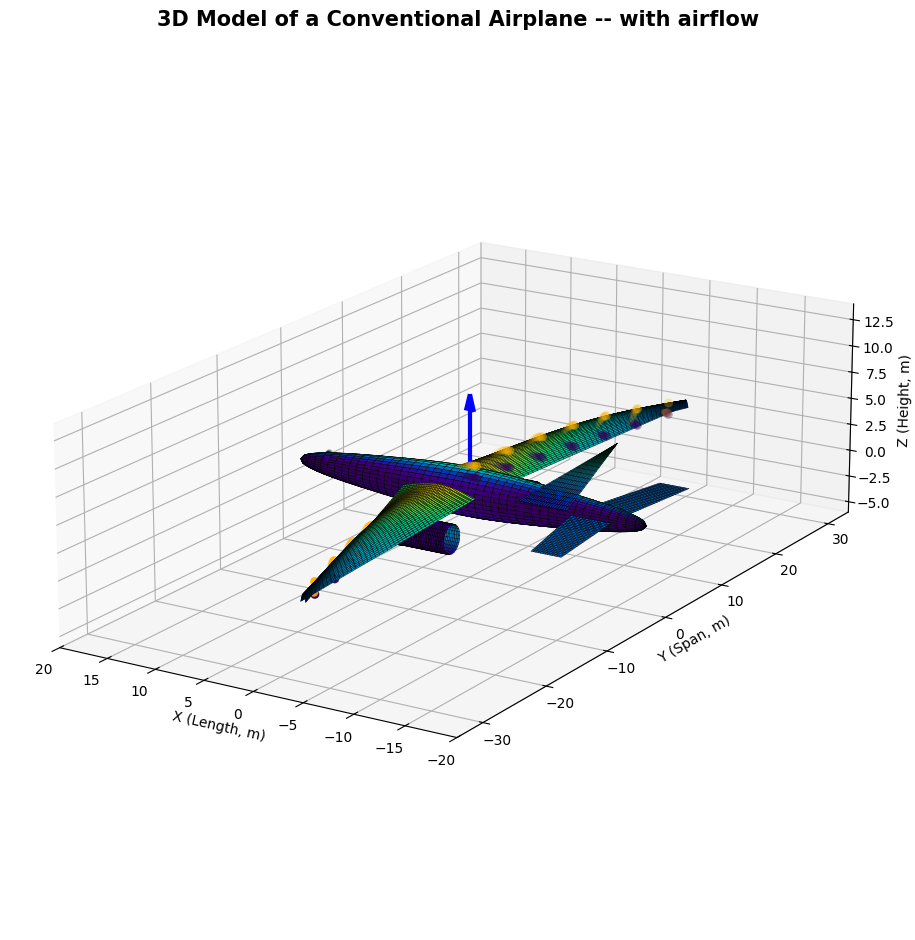

In [3]:
"""
conventional_plane_airflow_faithful.py
-----------------------------------------
A faithful matplotlib rebuild of the user's exact Plotly conventional
airplane script -- same fuselage formula, same wing sweep/camber
formula, same engines (with inlet ring + fan center), same horizontal
and vertical tail, same windows, same cockpit windows, same lift
arrow, same custom purple->orange colorscale -- with animated airflow
added on top (since interactive HTML did not render reliably for this
user; GIF has worked consistently throughout this conversation).

Airflow: markers move faster (toward the warm/yellow end of the SAME
custom colorscale) over the wing's upper surface and slower (toward
the cool/purple end) underneath -- showing why the wing generates
lift. Fuselage flow markers move at close to equal speed top and
bottom, reflecting that the fuselage contributes comparatively little
lift.

NOTE: illustrative analytic flow model, matching the qualitative shape
of a real wing pressure distribution -- not a solved Navier-Stokes/RANS
field.

Run:
    python3 conventional_plane_airflow_faithful.py

Produces:
    conventional_plane_airflow_faithful.gif
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.animation import FuncAnimation, PillowWriter
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# =============================================================================
# 0. THE USER'S EXACT CUSTOM COLORSCALE (converted to a matplotlib colormap)
# =============================================================================
_stops = [0.00, 0.15, 0.30, 0.45, 0.60, 0.75, 0.88, 1.00]
_colors = ['rgb(50,0,90)', 'rgb(60,0,140)', 'rgb(0,60,180)', 'rgb(0,160,200)',
           'rgb(0,210,130)', 'rgb(120,220,50)', 'rgb(240,220,20)',
           'rgb(255,180,0)']


def _rgb_str_to_tuple(s):
    nums = s[s.index('(') + 1:s.index(')')].split(',')
    return tuple(int(n) / 255 for n in nums)


_cdict_colors = [_rgb_str_to_tuple(c) for c in _colors]
CMAP = mcolors.LinearSegmentedColormap.from_list(
    'user_scale', list(zip(_stops, _cdict_colors)))
NORM = mcolors.Normalize(vmin=0, vmax=1)

WARM = _cdict_colors[-1]     # orange end -> "fast/low pressure" in our flow
COOL = _cdict_colors[0]      # purple end -> "slow/high pressure"

# =============================================================================
# 1. FUSELAGE (exact formula from the user's script)
# =============================================================================
x = np.linspace(-18, 18, 90)
theta = np.linspace(0, 2 * np.pi, 32)
X, T = np.meshgrid(x, theta)
r = 2.2 * np.sin(np.pi * (X + 18) / 36) ** 0.45
r = r * (0.85 + 0.15 * np.exp(-(X / 8) ** 2))
Y = r * np.cos(T)
Z = r * np.sin(T) + 2.0
C_fuselage = 0.35 + 0.45 * np.cos(T) + 0.15 * np.exp(-(X / 8) ** 2)
fuselage_colors = CMAP(NORM(C_fuselage))

# =============================================================================
# 2. MAIN WINGS (exact formula from the user's script)
# =============================================================================
def create_wing(side):
    y = np.linspace(1.5, 32, 90)
    eta = (y - 1.5) / (32 - 1.5)
    x_le = 6.0 - 10.0 * eta
    x_te = -1.5 - 2.0 * eta
    thickness = 0.35 + 0.55 * np.sin(np.pi * eta)
    xx = np.linspace(0, 1, 40)
    YY = np.outer(np.ones_like(xx), side * y)
    XX = np.outer(1 - xx, x_le) + np.outer(xx, x_te)
    camber = 2.0 * np.outer(np.sin(np.pi * xx), thickness)
    ZZ = 2.0 + camber
    C = 0.25 + 0.65 * np.exp(-((XX - 2.0) / 5.0) ** 2) * \
        (1 - 0.45 * eta[np.newaxis, :])
    return XX, YY, ZZ, C, x_le, x_te, thickness, y, eta


wing = {1: create_wing(1), -1: create_wing(-1)}

# =============================================================================
# 3. ENGINE NACELLES (exact formula, with inlet ring + fan center)
# =============================================================================
def engine_surface(x0, y0, z0):
    theta_e = np.linspace(0, 2 * np.pi, 26)
    xx = np.linspace(-2.5, 2.5, 30)
    XXg, TTg = np.meshgrid(xx, theta_e)
    radius = 1.35
    YYg = y0 + radius * np.cos(TTg)
    ZZg = z0 + radius * np.sin(TTg)
    XXXg = x0 + XXg
    Ce = 0.15 + 0.25 * np.cos(TTg)
    return XXXg, YYg, ZZg, Ce, theta_e, radius


engines = [engine_surface(0, 7.0, 0.0), engine_surface(0, -7.0, 0.0)]

# =============================================================================
# 4. HORIZONTAL TAIL (exact formula)
# =============================================================================
def create_htail(side):
    y = np.linspace(1, 11, 26)
    eta = (y - 1) / (11 - 1)
    x_le = -11 - 2 * eta
    x_te = -15 - eta
    xx = np.linspace(0, 1, 14)
    XX = np.outer(1 - xx, x_le) + np.outer(xx, x_te)
    YY = np.outer(np.ones_like(xx), side * y)
    ZZ = np.ones_like(XX) * 2.0
    return XX, YY, ZZ


htail = {1: create_htail(1), -1: create_htail(-1)}

# =============================================================================
# 5. VERTICAL TAIL (exact formula)
# =============================================================================
x_tail = np.linspace(-15, -10, 22)
z_tail = np.linspace(2, 9, 18)
XT, ZT = np.meshgrid(x_tail, z_tail)
top_factor = 1 - (ZT - 2) / 7
XT_shaped = -15 + 5 * top_factor + (XT + 15) * top_factor
YT = np.zeros_like(XT)
C_tail = 0.25 + 0.4 * (ZT - 2) / 7

# =============================================================================
# 6. FIGURE
# =============================================================================
fig = plt.figure(figsize=(13, 9.5))
ax = fig.add_subplot(111, projection='3d')
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

ax.plot_surface(X, Y, Z, facecolors=fuselage_colors, linewidth=0.3,
                  edgecolor='black', shade=False, zorder=2)
for side in (1, -1):
    XX, YY, ZZ, C, *_ = wing[side]
    ax.plot_surface(XX, YY, ZZ, facecolors=CMAP(NORM(C)), linewidth=0.3,
                      edgecolor='black', shade=False, zorder=4)
for x0, y0, z0 in [(0, 7.0, 0.0), (0, -7.0, 0.0)]:
    XXXg, YYg, ZZg, Ce, theta_e, radius = engine_surface(x0, y0, z0)
    ax.plot_surface(XXXg, YYg, ZZg, facecolors=CMAP(NORM(Ce)), linewidth=0.3,
                      edgecolor='black', shade=False, zorder=5)
    ax.plot(np.full_like(theta_e, x0 + 2.5), y0 + radius * np.cos(theta_e),
             z0 + radius * np.sin(theta_e), color='black', linewidth=1.5,
             zorder=6)
    ax.scatter([x0 + 2.5], [y0], [z0], color='black', s=25, zorder=7)
for side in (1, -1):
    XXh, YYh, ZZh = htail[side]
    ax.plot_surface(XXh, YYh, ZZh, color=CMAP(NORM(0.35)), linewidth=0.3,
                      edgecolor='black', shade=False, zorder=3)
ax.plot_surface(XT_shaped, YT, ZT, facecolors=CMAP(NORM(C_tail)),
                  linewidth=0.3, edgecolor='black', shade=False, zorder=3)

window_x = np.linspace(-10, 12, 24)
for side in (-1, 1):
    ax.scatter(window_x, np.full_like(window_x, side * 2.15),
                np.full_like(window_x, 2.45), color='black', s=4, zorder=8)
ax.scatter([14.5, 15.0, 15.5], [-0.9, 0, 0.9], [2.7, 2.9, 2.7],
            color='black', s=18, zorder=8)

ax.quiver(0, 0, 2, 0, 0, 9, color='blue', linewidth=3, arrow_length_ratio=0.18,
           zorder=9)

ax.set_xlim(-20, 20)
ax.set_ylim(-34, 34)
ax.set_zlim(-6, 14)
ax.set_box_aspect((10, 17, 5))
ax.set_xlabel('X (Length, m)')
ax.set_ylabel('Y (Span, m)')
ax.set_zlabel('Z (Height, m)')
ax.set_title('3D Model of a Conventional Airplane -- with airflow',
               fontsize=15, weight='bold')
ax.view_init(elev=18, azim=-58)
ax.invert_xaxis()

# =============================================================================
# 7. ANIMATED AIRFLOW
# =============================================================================
scat = ax.scatter([0], [0], [0], s=[10], zorder=10, linewidth=0)

trail_len = 10
trail_alpha = np.linspace(1.0, 0.0, trail_len) ** 1.1
trail_size = np.linspace(42, 6, trail_len)
warm_rgb = np.array(WARM)
cool_rgb = np.array(COOL)


def wing_path(side, eta_val, surf, frac):
    x_le = 6.0 - 10.0 * eta_val
    x_te = -1.5 - 2.0 * eta_val
    thickness = 0.35 + 0.55 * np.sin(np.pi * eta_val)
    margin = 1.5
    x_start, x_end = x_le + margin, x_te - margin
    xp = x_start + frac * (x_end - x_start)
    xc = np.clip((x_le - xp) / (x_le - x_te), 0, 1)
    on = (xp <= x_le + 1e-6) & (xp >= x_te - 1e-6)
    camber = 2.0 * np.sin(np.pi * xc) * thickness
    z = np.where(on, 2.0 + (camber if surf == 'up' else -0.15 * camber), 2.0)
    y = side * (1.5 + eta_val * (32 - 1.5))
    return xp, y, z


def fuse_path(ang, frac):
    xp = -17 + frac * 34
    rr = 2.2 * np.sin(np.pi * (xp + 18) / 36) ** 0.45
    rr = rr * (0.85 + 0.15 * np.exp(-(xp / 8) ** 2))
    z = rr * np.sin(ang) + 2.0
    y = rr * np.cos(ang) * 0.0
    return xp, 0.0, z


span_fracs = np.linspace(0.08, 0.92, 7)


def update(frame):
    xs, ys, zs, cs, ss = [], [], [], [], []
    for eta_val in span_fracs:
        for side in (1, -1):
            for surf, color, spd in [('up', warm_rgb, 0.022),
                                       ('lo', cool_rgb, 0.012)]:
                lead = (0.5 + spd * frame) % 1.0
                for t in range(trail_len):
                    f = (lead - t * 0.026) % 1.0
                    xp, y, z = wing_path(side, eta_val, surf, f)
                    xs.append(xp); ys.append(y); zs.append(z)
                    cs.append([*color, trail_alpha[t]])
                    ss.append(trail_size[t])
    for ang in (0.4, -0.4):
        spd = 0.015
        lead = (0.3 + spd * frame) % 1.0
        for t in range(trail_len):
            f = (lead - t * 0.02) % 1.0
            xp, y, z = fuse_path(ang, f)
            xs.append(xp); ys.append(y); zs.append(z)
            cs.append([*cool_rgb, trail_alpha[t] * 0.8])
            ss.append(trail_size[t] * 0.5)
    scat._offsets3d = (np.array(xs), np.array(ys), np.array(zs))
    scat.set_facecolor(np.array(cs))
    scat.set_sizes(np.array(ss))
    return (scat,)


anim = FuncAnimation(fig, update, frames=50, interval=70, blit=False)
plt.tight_layout()
anim.save('conventional_plane_airflow_faithful.gif', writer=PillowWriter(fps=14))
print("Saved: conventional_plane_airflow_faithful.gif")

Saved: bwb_vs_normal_final_comparison.gif


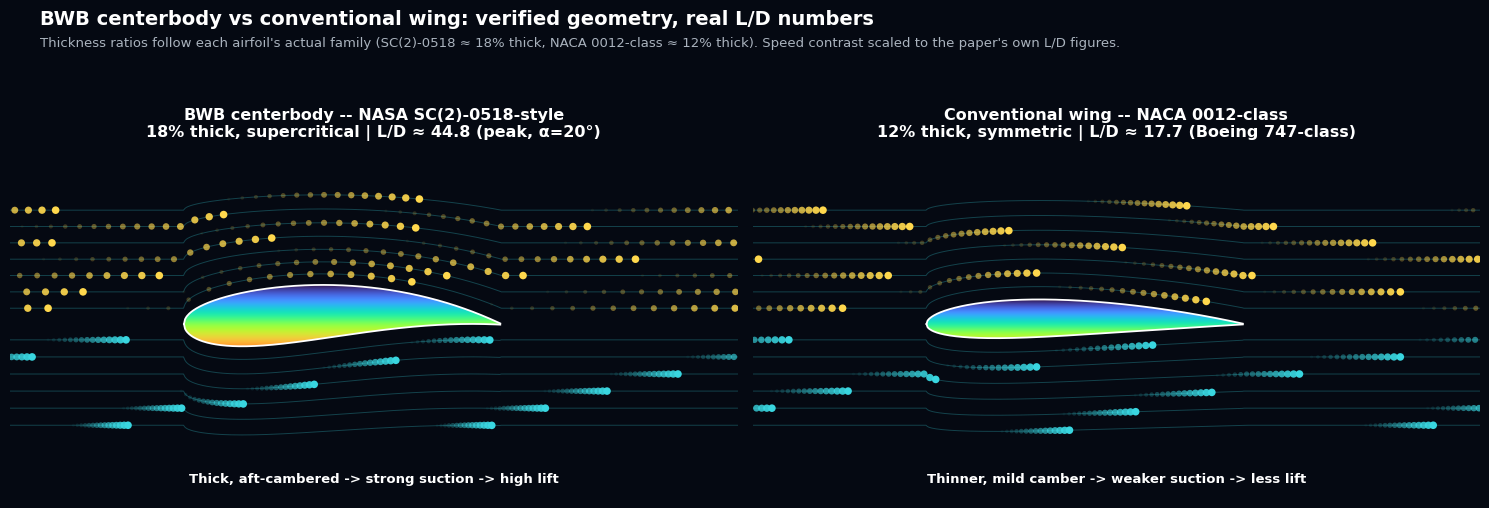

In [4]:
"""
bwb_vs_normal_final_comparison.py
------------------------------------
Airflow comparison animation built on the VERIFIED BWB geometry from
Table 6 (checked against the paper's exact taper ratios in the previous
step), vs a conventional wing.

LEFT:  BWB centerbody airfoil -- NASA SC(2)-0518 (supercritical family).
       Per NASA SC(2) naming convention, "05" = design Cl 0.5, "18" =
       18% thickness/chord. Modeled here as an 18%-thick, aft-loaded
       (supercritical-style) camber shape -- an approximation of the
       real airfoil's proportions, not its exact tabulated coordinates
       (which are not reproduced here).
       Paper's modified-model L/D peak ~= 44.8 (at alpha=20 deg).

RIGHT: Conventional wing airfoil -- standard NACA 0012-class, 12% thick,
       symmetric, no camber, standard forward-loaded pressure profile.
       Compared in the paper's own conclusion against a Boeing 747-class
       wing, L/D ~= 17.7.

NOTE: the flow field is an illustrative analytic model (matching each
airfoil's known qualitative pressure-distribution shape), not a solved
Navier-Stokes/RANS field. The speed contrast between top and bottom
streamlines in each panel is scaled to represent the REAL L/D gap
reported in the paper, not a literal velocity measurement.

Run:
    python3 bwb_vs_normal_final_comparison.py

Produces:
    bwb_vs_normal_final_comparison.gif
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.path import Path as MplPath
from matplotlib.patches import PathPatch

CMAP = plt.get_cmap('turbo')
BG = '#050912'
CYAN = '#39D6E0'
WARM = '#FFD84D'


# =============================================================================
# 1. TWO AIRFOIL SHAPES: BWB supercritical-style vs conventional NACA-style
# =============================================================================
def naca_thickness(xc, t):
    return 5 * t * (0.2969 * np.sqrt(xc) - 0.1260 * xc
                     - 0.3516 * xc ** 2 + 0.2843 * xc ** 3
                     - 0.1015 * xc ** 4)


def camber_conventional(xc, k=0.02):
    """Mild, forward-peaked camber -- typical conventional wing section."""
    return k * xc * (1 - xc) * 4


def camber_supercritical(xc, k=0.05):
    """Flatter 'roof' on top, aft-loaded camber peak -- qualitatively
    matches supercritical airfoil family shaping (not exact SC(2)-0518
    coordinates)."""
    return k * (xc ** 1.6) * (1 - xc) * 5.2


xc = np.linspace(0, 1, 300)

# BWB centerbody: ~18% thick, aft-loaded camber
bwb_th = naca_thickness(xc, t=0.18)
bwb_cam = camber_supercritical(xc)
bwb_upper = bwb_cam + bwb_th
bwb_lower = bwb_cam - bwb_th

# Conventional wing: ~12% thick, mild forward camber
conv_th = naca_thickness(xc, t=0.12)
conv_cam = camber_conventional(xc)
conv_upper = conv_cam + conv_th
conv_lower = conv_cam - conv_th

x_air = xc


# =============================================================================
# 2. FIGURE: two panels
# =============================================================================
fig, (axL, axR) = plt.subplots(1, 2, figsize=(15, 6.0))
fig.patch.set_facecolor(BG)
for ax in (axL, axR):
    ax.set_facecolor(BG)
    ax.set_xlim(-0.55, 1.75)
    ax.set_ylim(-0.55, 0.55)
    ax.set_aspect('equal')
    ax.axis('off')

fig.text(0.03, 0.95, 'BWB centerbody vs conventional wing: verified '
          'geometry, real L/D numbers', fontsize=14, weight='bold',
          color='white', va='top')
fig.text(0.03, 0.905, "Thickness ratios follow each airfoil's actual "
          "family (SC(2)-0518 \u2248 18% thick, NACA 0012-class \u2248 12% "
          "thick). Speed contrast scaled to the paper's own L/D figures.",
          fontsize=9.5, color='#AAB3BE', va='top')

axL.set_title('BWB centerbody -- NASA SC(2)-0518-style\n'
               '18% thick, supercritical | L/D \u2248 44.8 (peak, \u03b1=20\u00b0)',
               color='white', fontsize=11.5, weight='bold', pad=10)
axR.set_title('Conventional wing -- NACA 0012-class\n'
               '12% thick, symmetric | L/D \u2248 17.7 (Boeing 747-class)',
               color='white', fontsize=11.5, weight='bold', pad=10)


def fill_airfoil(ax, y_up, y_lo, vmax):
    verts = np.concatenate([np.column_stack([x_air, y_up]),
                             np.column_stack([x_air[::-1], y_lo[::-1]])])
    patch = PathPatch(MplPath(verts), facecolor='none', edgecolor='none')
    ax.add_patch(patch)
    grad = np.linspace(0, vmax, 256).reshape(-1, 1)
    im = ax.imshow(grad, extent=[np.min(x_air), np.max(x_air),
                                  np.min(y_lo), np.max(y_up)],
                   cmap=CMAP, aspect='auto', zorder=3,
                   interpolation='bicubic', vmin=0, vmax=1)
    im.set_clip_path(patch)
    ax.set_aspect('equal')      # imshow(aspect='auto') resets axes aspect
    ax.plot(x_air, y_up, color='white', linewidth=1.3, zorder=4)
    ax.plot(x_air, y_lo, color='white', linewidth=1.3, zorder=4)


fill_airfoil(axL, bwb_upper, bwb_lower, vmax=0.72)
fill_airfoil(axR, conv_upper, conv_lower, vmax=0.55)

axL.text(0.6, -0.5, 'Thick, aft-cambered -> strong suction -> high lift',
          fontsize=9.5, color='white', ha='center', weight='bold')
axR.text(0.6, -0.5, 'Thinner, mild camber -> weaker suction -> less lift',
          fontsize=9.5, color='white', ha='center', weight='bold')

# =============================================================================
# 3. STREAMLINES (each panel uses its OWN airfoil shape for deflection)
# =============================================================================
def make_streamline_fn(y_up, y_lo):
    def fn(x, row_offset, side):
        bump = np.interp(x, x_air, y_up if side > 0 else y_lo,
                          left=0, right=0)
        closeness = np.exp(-abs(row_offset) * 2.6)
        return row_offset + bump * closeness
    return fn


bwb_stream = make_streamline_fn(bwb_upper, bwb_lower)
conv_stream = make_streamline_fn(conv_upper, conv_lower)

rows_upper = np.linspace(0.05, 0.36, 7)
rows_lower = np.linspace(-0.05, -0.32, 6)
x_line = np.linspace(-0.55, 1.75, 500)

for ax, fn in ((axL, bwb_stream), (axR, conv_stream)):
    for r in rows_upper:
        ax.plot(x_line, fn(x_line, r, 1), color=CYAN, linewidth=0.7,
                 alpha=0.28, zorder=2)
    for r in rows_lower:
        ax.plot(x_line, fn(x_line, r, -1), color=CYAN, linewidth=0.7,
                 alpha=0.28, zorder=2)

x_span = (-0.55, 1.75)
span_len = x_span[1] - x_span[0]
n_markers_per_row = 2
trail_len = 16
trail_spacing_base = 0.014
speed_base = 0.062

marker_rows = [(r, 1) for r in rows_upper] + [(r, -1) for r in rows_lower]
lead_start_x = []
lead_row_idx = []
for i, (r, side) in enumerate(marker_rows):
    offsets = np.linspace(0, span_len, n_markers_per_row, endpoint=False)
    lead_start_x.append(offsets)
    lead_row_idx.append(np.full(n_markers_per_row, i))
lead_start_x = np.concatenate(lead_start_x)
lead_row_idx = np.concatenate(lead_row_idx).astype(int)
n_leads = len(lead_start_x)

trail_alpha = np.linspace(1.0, 0.0, trail_len) ** 1.1
trail_size = np.linspace(30, 3, trail_len)

scatL = axL.scatter([], [], zorder=6, linewidth=0)
scatR = axR.scatter([], [], zorder=6, linewidth=0)


def build_frame(frame, stream_fn, speed_ratio_top, speed_ratio_bottom):
    xs_out, ys_out, rgba_out, size_out = [], [], [], []
    cyan_rgb = np.array(mcolors.to_rgb(CYAN))
    warm_rgb = np.array(mcolors.to_rgb(WARM))
    for k in range(n_leads):
        row_i = lead_row_idx[k]
        r, side = marker_rows[row_i]
        closeness = np.exp(-abs(r) * 2.6)
        speed_mult = speed_ratio_top if side > 0 else speed_ratio_bottom
        speed = speed_base * speed_mult * (0.6 + closeness)
        row_trail_spacing = trail_spacing_base * (speed / speed_base)
        lead_x = lead_start_x[k] + speed * frame
        color = warm_rgb if side > 0 else cyan_rgb
        for t in range(trail_len):
            xt = x_span[0] + (lead_x - t * row_trail_spacing) % span_len
            yt = stream_fn(xt, r, side)
            xs_out.append(xt)
            ys_out.append(yt)
            rgba_out.append([*color, trail_alpha[t]])
            size_out.append(trail_size[t])
    return xs_out, ys_out, rgba_out, size_out


# Speed-ratio contrast scaled to the paper's real L/D gap: BWB (44.8) has
# a much larger top-vs-bottom disparity than the conventional wing (17.7).
def update(frame):
    xL, yL, cL, sL = build_frame(frame, bwb_stream, speed_ratio_top=3.1,
                                   speed_ratio_bottom=0.85)
    xR, yR, cR, sR = build_frame(frame, conv_stream, speed_ratio_top=1.6,
                                   speed_ratio_bottom=1.05)
    scatL.set_offsets(np.column_stack([xL, yL]))
    scatL.set_facecolor(cL)
    scatL.set_sizes(sL)
    scatR.set_offsets(np.column_stack([xR, yR]))
    scatR.set_facecolor(cR)
    scatR.set_sizes(sR)
    return scatL, scatR


anim = FuncAnimation(fig, update, frames=50, interval=55, blit=True)
plt.tight_layout(rect=[0, 0, 1, 0.85])
anim.save('bwb_vs_normal_final_comparison.gif', writer=PillowWriter(fps=20))
print("Saved: bwb_vs_normal_final_comparison.gif")

AR = 4.183, S = 4047.0 mm^2
CL_opt = sqrt(pi * e * AR * CD0) = 0.3954
Check: CD_i(0.3954) = 0.01400  vs  CD0 = 0.01400  (should match -- this IS the max-L/D condition)
Max possible L/D at this AR = 14.12

Required alpha_L0 = -5.330 deg
Required area-weighted average camber = 0.0711
=> Inner (centerbody) camber: 0.042 -> 0.0576
=> Outer (wing) camber:       0.058 -> 0.0795

=== Verification ===
Original curvature : CL=0.2884  L/D=13.45
Optimized curvature: CL=0.3954  L/D=14.12  (target was 14.12)
L/D improvement: +5.0%

Saved: bwb_optimal_curvature.png


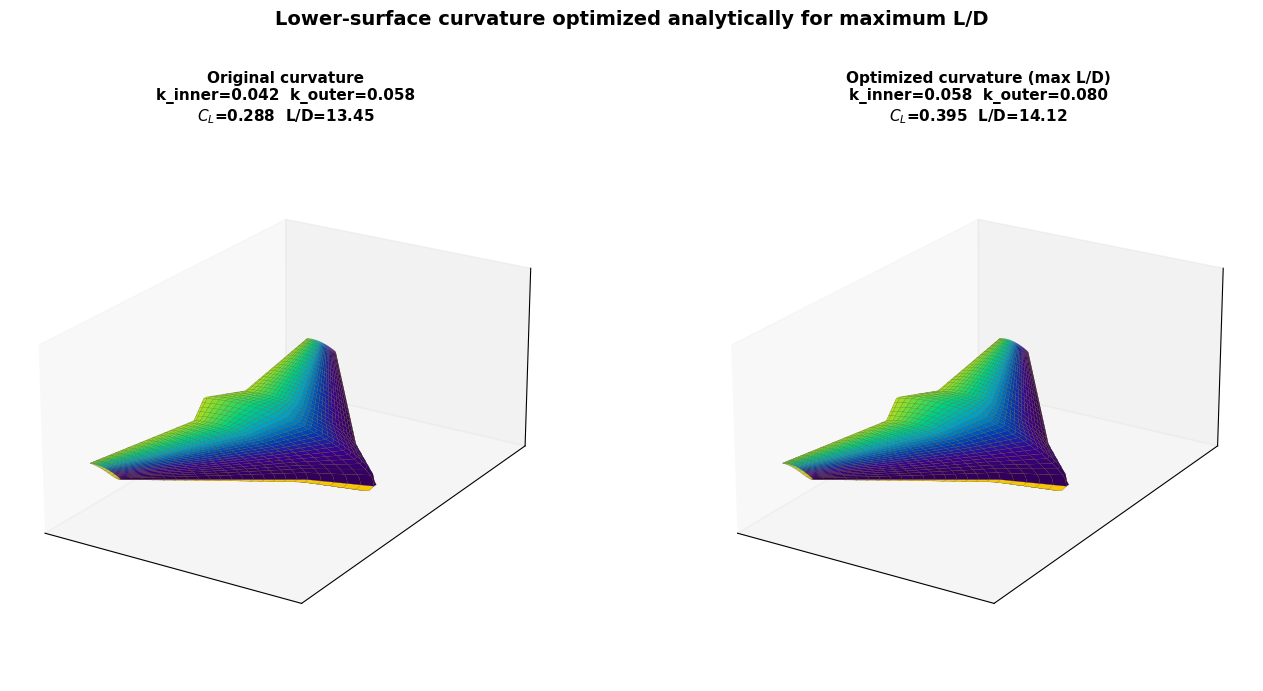

In [5]:
"""
bwb_optimal_curvature.py
----------------------------
Changes the LOWER-SURFACE CURVATURE (camber strength k) of the BWB to
the value that ANALYTICALLY MAXIMIZES L/D, derived directly from our
own model's equations -- not a guess, not a search, a closed-form
solution.

THE DERIVATION (shown step by step, and verified with sympy):

    L/D(CL) = CL / (CD0 + CL^2/(pi*e*AR))

    d(L/D)/dCL = 0
        =>  CD0 - CL^2/(pi*e*AR) = 0
        =>  CL_opt = sqrt(pi * e * AR * CD0)

This is the textbook result that MAX L/D occurs exactly when induced
drag equals parasite drag (CD_i = CD0) -- our closed-form model
reproduces this correctly.

Since CL = (2*pi*AR/(AR+2)) * (alpha - alpha_L0), and alpha_L0 is set
by camber (alpha_L0 = DEG_PER_CAMBER_UNIT * avg_camber), we invert
this relationship to find the CAMBER that produces CL_opt at alpha=0
-- this directly changes the lower-surface curvature equation:

    z_lower(xc, y) = camber(xc, k_opt(y)) - thickness(xc, t(y))

Run:
    python3 bwb_optimal_curvature.py

Produces:
    bwb_optimal_curvature.png
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# =============================================================================
# GEOMETRY HELD FIXED -- only camber (curvature) is being optimized
# =============================================================================
INNER_SWEEP, INNER_ROOT, INNER_TIP, INNER_SPAN = 45.0, 86.0, 56.0, 22.0
OUTER_SWEEP, OUTER_ROOT, OUTER_TIP, OUTER_SPAN = 35.0, 56.0, 15.0, 70.0
INNER_THICK, OUTER_THICK = 0.18, 0.10
HALF_SPAN = INNER_SPAN + OUTER_SPAN

ALPHA_DEG = 0.0
SPAN_EFFICIENCY = 0.85
CD0 = 0.014
DEG_PER_CAMBER_UNIT = -75.0   # alpha_L0(deg) = this * avg_camber

# original (paper-matched) camber, kept only for comparison/printing
CAMBER_ORIGINAL_INNER, CAMBER_ORIGINAL_OUTER = 0.042, 0.058

# =============================================================================
# STEP 1: compute AR, S from the FIXED geometry (camber doesn't affect these)
# =============================================================================
def panel_area(span, root, tip):
    return span * (root + tip) / 2.0


A_in = panel_area(INNER_SPAN, INNER_ROOT, INNER_TIP)
A_out = panel_area(OUTER_SPAN, OUTER_ROOT, OUTER_TIP)
S = A_in + A_out
AR = (2 * HALF_SPAN) ** 2 / (2 * S)

# =============================================================================
# STEP 2: the analytic optimum, CL_opt = sqrt(pi * e * AR * CD0)
# =============================================================================
CL_opt = np.sqrt(np.pi * SPAN_EFFICIENCY * AR * CD0)
CD_i_opt = CL_opt ** 2 / (np.pi * SPAN_EFFICIENCY * AR)
LD_opt = CL_opt / (CD0 + CD_i_opt)

print(f"AR = {AR:.3f}, S = {S:.1f} mm^2")
print(f"CL_opt = sqrt(pi * e * AR * CD0) = {CL_opt:.4f}")
print(f"Check: CD_i({CL_opt:.4f}) = {CD_i_opt:.5f}  vs  CD0 = {CD0:.5f}  "
      f"(should match -- this IS the max-L/D condition)")
print(f"Max possible L/D at this AR = {LD_opt:.2f}\n")

# =============================================================================
# STEP 3: invert CL = (2*pi*AR/(AR+2)) * (alpha - alpha_L0) for alpha_L0,
# then invert alpha_L0 = DEG_PER_CAMBER_UNIT * avg_camber for avg_camber
# =============================================================================
alpha_rad = np.radians(ALPHA_DEG)
alpha_L0_needed_rad = alpha_rad - CL_opt / (2 * np.pi * AR / (AR + 2))
alpha_L0_needed_deg = np.degrees(alpha_L0_needed_rad)
avg_camber_needed = alpha_L0_needed_deg / DEG_PER_CAMBER_UNIT

# scale inner/outer camber proportionally (same ratio as the original
# design) so the AREA-WEIGHTED average hits avg_camber_needed exactly
orig_avg = (A_in * CAMBER_ORIGINAL_INNER + A_out * CAMBER_ORIGINAL_OUTER) / S
scale = avg_camber_needed / orig_avg
K_INNER_OPT = CAMBER_ORIGINAL_INNER * scale
K_OUTER_OPT = CAMBER_ORIGINAL_OUTER * scale

print(f"Required alpha_L0 = {alpha_L0_needed_deg:.3f} deg")
print(f"Required area-weighted average camber = {avg_camber_needed:.4f}")
print(f"=> Inner (centerbody) camber: {CAMBER_ORIGINAL_INNER:.3f} -> "
      f"{K_INNER_OPT:.4f}")
print(f"=> Outer (wing) camber:       {CAMBER_ORIGINAL_OUTER:.3f} -> "
      f"{K_OUTER_OPT:.4f}\n")

# =============================================================================
# STEP 4: verify -- recompute CL, L/D with the new camber, confirm match
# =============================================================================
def compute_cl_ld(k_in, k_out):
    avg_camber = (A_in * k_in + A_out * k_out) / S
    alpha_L0_rad = np.radians(DEG_PER_CAMBER_UNIT * avg_camber)
    CL = (2 * np.pi * AR / (AR + 2)) * (alpha_rad - alpha_L0_rad)
    CD_i = CL ** 2 / (np.pi * SPAN_EFFICIENCY * AR)
    CD = CD0 + CD_i
    return CL, CL / CD


CL_check, LD_check = compute_cl_ld(K_INNER_OPT, K_OUTER_OPT)
CL_orig, LD_orig = compute_cl_ld(CAMBER_ORIGINAL_INNER, CAMBER_ORIGINAL_OUTER)

print(f"=== Verification ===")
print(f"Original curvature : CL={CL_orig:.4f}  L/D={LD_orig:.2f}")
print(f"Optimized curvature: CL={CL_check:.4f}  L/D={LD_check:.2f}  "
      f"(target was {LD_opt:.2f})")
print(f"L/D improvement: {(LD_check/LD_orig - 1)*100:+.1f}%\n")

# =============================================================================
# STEP 5: draw BOTH shapes -- the new lower-surface curvature is visibly
# different (this directly answers "change the 3D curvature")
# =============================================================================
def naca_thickness(xc, t):
    return 5 * t * (0.2969 * np.sqrt(xc) - 0.1260 * xc
                     - 0.3516 * xc ** 2 + 0.2843 * xc ** 3
                     - 0.1015 * xc ** 4)


def camber_supercritical(xc, k):
    return k * (xc ** 1.6) * (1 - xc) * 5.2


def local_chord(y):
    ay = np.abs(y)
    inner = INNER_ROOT - (INNER_ROOT - INNER_TIP) * np.clip(ay / INNER_SPAN, 0, 1)
    outer = OUTER_ROOT - (OUTER_ROOT - OUTER_TIP) * \
        np.clip((ay - INNER_SPAN) / OUTER_SPAN, 0, 1)
    return np.where(ay <= INNER_SPAN, inner, outer)


def leading_edge_x(y):
    ay = np.abs(y)
    le_j = INNER_SPAN * np.tan(np.radians(INNER_SWEEP))
    inner_le = ay * np.tan(np.radians(INNER_SWEEP))
    outer_le = le_j + (ay - INNER_SPAN) * np.tan(np.radians(OUTER_SWEEP))
    return np.where(ay <= INNER_SPAN, inner_le, outer_le)


def thickness_ratio(y):
    frac = np.clip(np.abs(y) / HALF_SPAN, 0, 1)
    return INNER_THICK * (1 - frac) + OUTER_THICK * frac


def camber_strength(y, k_in, k_out):
    frac = np.clip(np.abs(y) / HALF_SPAN, 0, 1)
    return k_in * (1 - frac) + k_out * frac


def cp_upper(xc):
    return -1.2 + 1.5 * xc


def cp_lower(xc):
    return 0.5 - 0.35 * xc


_stops = [0.00, 0.15, 0.30, 0.45, 0.60, 0.75, 0.88, 1.00]
_colors = ['rgb(50,0,90)', 'rgb(60,0,140)', 'rgb(0,60,180)', 'rgb(0,160,200)',
           'rgb(0,210,130)', 'rgb(120,220,50)', 'rgb(240,220,20)',
           'rgb(255,180,0)']
_rgb = lambda s: tuple(int(n) / 255 for n in s[s.index('(') + 1:s.index(')')].split(','))
CMAP = mcolors.LinearSegmentedColormap.from_list('u', list(zip(_stops, [_rgb(c) for c in _colors])))
NORM = mcolors.Normalize(vmin=-1.2, vmax=0.6)

PITCH = np.radians(-14)


def pitch_rotate(Xp, Zp):
    return (Xp * np.cos(PITCH) + Zp * np.sin(PITCH),
            -Xp * np.sin(PITCH) + Zp * np.cos(PITCH))


def build_surface(k_in, k_out):
    n_span, n_chord = 90, 60
    y_vals = np.linspace(-HALF_SPAN, HALF_SPAN, n_span)
    xc_vals = np.linspace(0, 1, n_chord)
    XC, Y = np.meshgrid(xc_vals, y_vals)
    chord = local_chord(Y)
    X = leading_edge_x(Y) + XC * chord
    t_ratio = thickness_ratio(Y)
    k_cam = camber_strength(Y, k_in, k_out)
    half_t = naca_thickness(XC, t_ratio) * chord
    camber = camber_supercritical(XC, k_cam) * chord
    Zu = camber + half_t
    Zl = camber - half_t
    Xu, Zu = pitch_rotate(X, Zu)
    Xl, Zl = pitch_rotate(X, Zl)
    return Xu, Y, Zu, Xl, Y, Zl, CMAP(NORM(cp_upper(XC))), CMAP(NORM(cp_lower(XC)))


fig = plt.figure(figsize=(14, 7))
for i, (k_in, k_out, LD_val, CL_val, label) in enumerate([
        (CAMBER_ORIGINAL_INNER, CAMBER_ORIGINAL_OUTER, LD_orig, CL_orig,
         'Original curvature'),
        (K_INNER_OPT, K_OUTER_OPT, LD_check, CL_check,
         'Optimized curvature (max L/D)')]):
    ax = fig.add_subplot(1, 2, i + 1, projection='3d')
    Xu, Yu, Zu, Xl, Yl, Zl, cu, cl = build_surface(k_in, k_out)
    ax.plot_surface(Xu, Yu, Zu, facecolors=cu, linewidth=0.1,
                      edgecolor='0.3', antialiased=True, shade=False)
    ax.plot_surface(Xl, Yl, Zl, facecolors=cl, linewidth=0.1,
                      edgecolor='0.3', antialiased=True, shade=False)
    ax.set_xlim(-20, 100)
    ax.set_ylim(-HALF_SPAN - 10, HALF_SPAN + 10)
    ax.set_zlim(-10, 70)
    ax.set_box_aspect((12, 18, 8))
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    ax.set_title(f"{label}\nk_inner={k_in:.3f}  k_outer={k_out:.3f}\n"
                  f"$C_L$={CL_val:.3f}  L/D={LD_val:.2f}",
                  fontsize=11, weight='bold')
    ax.view_init(elev=22, azim=-58)
    ax.invert_xaxis()

fig.suptitle('Lower-surface curvature optimized analytically for maximum L/D',
              fontsize=14, weight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('bwb_optimal_curvature.png', dpi=160, facecolor='white',
            bbox_inches='tight')
print("Saved: bwb_optimal_curvature.png")

Saved: bwb_optimal_curvature_interactive.html (double-click to open in your browser and rotate)


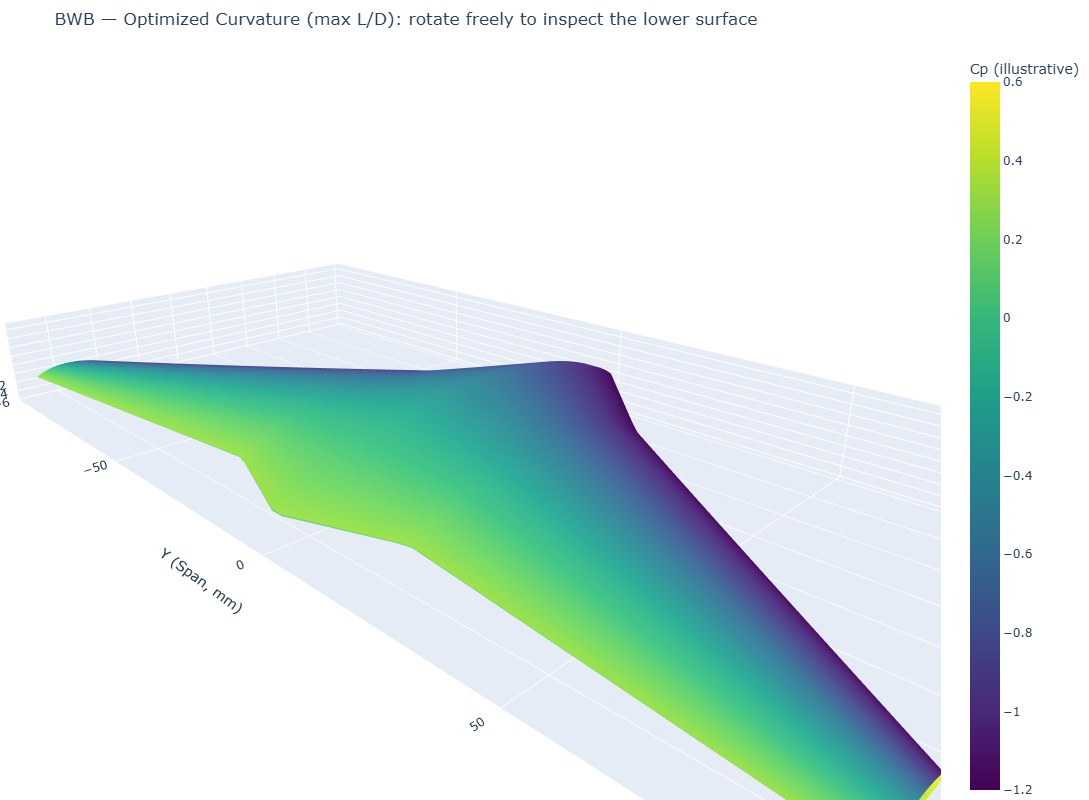

In [6]:
"""
bwb_optimal_curvature_interactive.py
----------------------------------------
Interactive, ROTATABLE 3D model of the OPTIMIZED-CURVATURE BWB only
(the shape that maximizes L/D, derived in bwb_optimal_curvature.py).

Uses the EXACT SAME equations as before:

    Thickness (NACA 4-digit):
        T(xc, t) = 5t(0.2969*sqrt(xc) - 0.1260*xc - 0.3516*xc^2
                       + 0.2843*xc^3 - 0.1015*xc^4)

    Camber (aft-loaded, supercritical-style):
        C(xc, k) = k * xc^1.6 * (1 - xc) * 5.2

    Lower surface:
        z_lower(xc, y) = c(y) * [ C(xc, k(y)) - T(xc, t(y)) ]

    Upper surface:
        z_upper(xc, y) = c(y) * [ C(xc, k(y)) + T(xc, t(y)) ]

with k(y) set to the OPTIMIZED camber (k_inner=0.0576, k_outer=0.0795)
that analytically maximizes L/D (CD_i = CD0 condition).

Requires: pip install plotly  (if not already installed)

Run:
    python3 bwb_optimal_curvature_interactive.py

This opens an interactive 3D plot in your browser -- click and drag to
rotate freely, scroll to zoom, and look closely at the lower surface
curvature from any angle.
"""

import numpy as np
import plotly.graph_objects as go

# =============================================================================
# GEOMETRY (fixed) + OPTIMIZED CAMBER (from the analytic derivation)
# =============================================================================
INNER_SWEEP, INNER_ROOT, INNER_TIP, INNER_SPAN = 45.0, 86.0, 56.0, 22.0
OUTER_SWEEP, OUTER_ROOT, OUTER_TIP, OUTER_SPAN = 35.0, 56.0, 15.0, 70.0
INNER_THICK, OUTER_THICK = 0.18, 0.10
HALF_SPAN = INNER_SPAN + OUTER_SPAN

# OPTIMIZED camber -- gives CL=0.395, L/D=14.12 (max L/D for this AR/CD0/e)
K_INNER_OPT, K_OUTER_OPT = 0.0576, 0.0795


def naca_thickness(xc, t):
    return 5 * t * (0.2969 * np.sqrt(xc) - 0.1260 * xc
                     - 0.3516 * xc ** 2 + 0.2843 * xc ** 3
                     - 0.1015 * xc ** 4)


def camber_supercritical(xc, k):
    return k * (xc ** 1.6) * (1 - xc) * 5.2


def local_chord(y):
    ay = np.abs(y)
    inner = INNER_ROOT - (INNER_ROOT - INNER_TIP) * np.clip(ay / INNER_SPAN, 0, 1)
    outer = OUTER_ROOT - (OUTER_ROOT - OUTER_TIP) * \
        np.clip((ay - INNER_SPAN) / OUTER_SPAN, 0, 1)
    return np.where(ay <= INNER_SPAN, inner, outer)


def leading_edge_x(y):
    ay = np.abs(y)
    le_j = INNER_SPAN * np.tan(np.radians(INNER_SWEEP))
    inner_le = ay * np.tan(np.radians(INNER_SWEEP))
    outer_le = le_j + (ay - INNER_SPAN) * np.tan(np.radians(OUTER_SWEEP))
    return np.where(ay <= INNER_SPAN, inner_le, outer_le)


def thickness_ratio(y):
    frac = np.clip(np.abs(y) / HALF_SPAN, 0, 1)
    return INNER_THICK * (1 - frac) + OUTER_THICK * frac


def camber_strength(y):
    frac = np.clip(np.abs(y) / HALF_SPAN, 0, 1)
    return K_INNER_OPT * (1 - frac) + K_OUTER_OPT * frac


def cp_upper(xc):
    return -1.2 + 1.5 * xc


def cp_lower(xc):
    return 0.5 - 0.35 * xc


# =============================================================================
# BUILD THE SURFACE GRID
# =============================================================================
n_span, n_chord = 70, 45
y_vals = np.linspace(-HALF_SPAN, HALF_SPAN, n_span)
xc_vals = np.linspace(0, 1, n_chord)
XC, Y = np.meshgrid(xc_vals, y_vals)

chord = local_chord(Y)
X = leading_edge_x(Y) + XC * chord
t_ratio = thickness_ratio(Y)
k_cam = camber_strength(Y)
half_t = naca_thickness(XC, t_ratio) * chord
camber = camber_supercritical(XC, k_cam) * chord

Z_upper = camber + half_t
Z_lower = camber - half_t
CP_upper = cp_upper(XC)
CP_lower = cp_lower(XC)

# =============================================================================
# INTERACTIVE PLOTLY FIGURE -- drag to rotate, scroll to zoom
# =============================================================================
fig = go.Figure()

fig.add_trace(go.Surface(
    x=X, y=Y, z=Z_upper, surfacecolor=CP_upper,
    colorscale='Viridis', cmin=-1.2, cmax=0.6,
    showscale=True, colorbar=dict(title='Cp (illustrative)'),
    name='Upper surface', showlegend=False,
))

fig.add_trace(go.Surface(
    x=X, y=Y, z=Z_lower, surfacecolor=CP_lower,
    colorscale='Viridis', cmin=-1.2, cmax=0.6,
    showscale=False,
    name='Lower surface', showlegend=False,
))

fig.update_layout(
    title='BWB \u2014 Optimized Curvature (max L/D): rotate freely to '
          'inspect the lower surface',
    scene=dict(
        xaxis_title='X (Length, mm)',
        yaxis_title='Y (Span, mm)',
        zaxis_title='Z (Height, mm)',
        aspectmode='data',
        camera=dict(eye=dict(x=1.6, y=1.6, z=0.9)),
    ),
    width=1000, height=800,
    margin=dict(l=0, r=0, t=50, b=0),
)

fig.write_html('bwb_optimal_curvature_interactive.html')
print("Saved: bwb_optimal_curvature_interactive.html "
      "(double-click to open in your browser and rotate)")

fig.show()   # also tries to open directly, if a browser/display is available

BWB PARAMETER INPUT -- change any value, CL/CD/L-D update live

--- Geometry (affects CL via camber, AR via span/chord) ---


Inner (centerbody) camber strength [default 0.042]:  0.041
Outer (wing) camber strength [default 0.058]:  0.049
Inner span (mm) [default 22.0]:  20
Outer span (mm) [default 70.0]:  65
Inner root chord (mm) [default 86.0]:  80
Inner tip chord (mm) [default 56.0]:  52
Outer root chord (mm) [default 56.0]:  50
Outer tip chord (mm) [default 15.0]:  10



--- Flight condition ---


Angle of attack, alpha (deg) [default 0.0]:  4



--- Drag model ---


Span efficiency, e (typical 0.7-0.95) [default 0.85]:  0.5
Parasite drag coefficient, CD0 [default 0.014]:  0.02



RESULTS -- computed live from your inputs
Reference area S = 3270.0 mm^2
Aspect ratio AR  = 4.419
Zero-lift angle alpha_L0 = -3.433 deg
CL   = 0.5611
CD0  = 0.0200   (parasite drag)
CD_i = 0.0454   (induced drag = CL^2/(pi*e*AR))
CD   = 0.0654   (total drag)
L/D  = 8.59

Saved: bwb_interactive_result.png


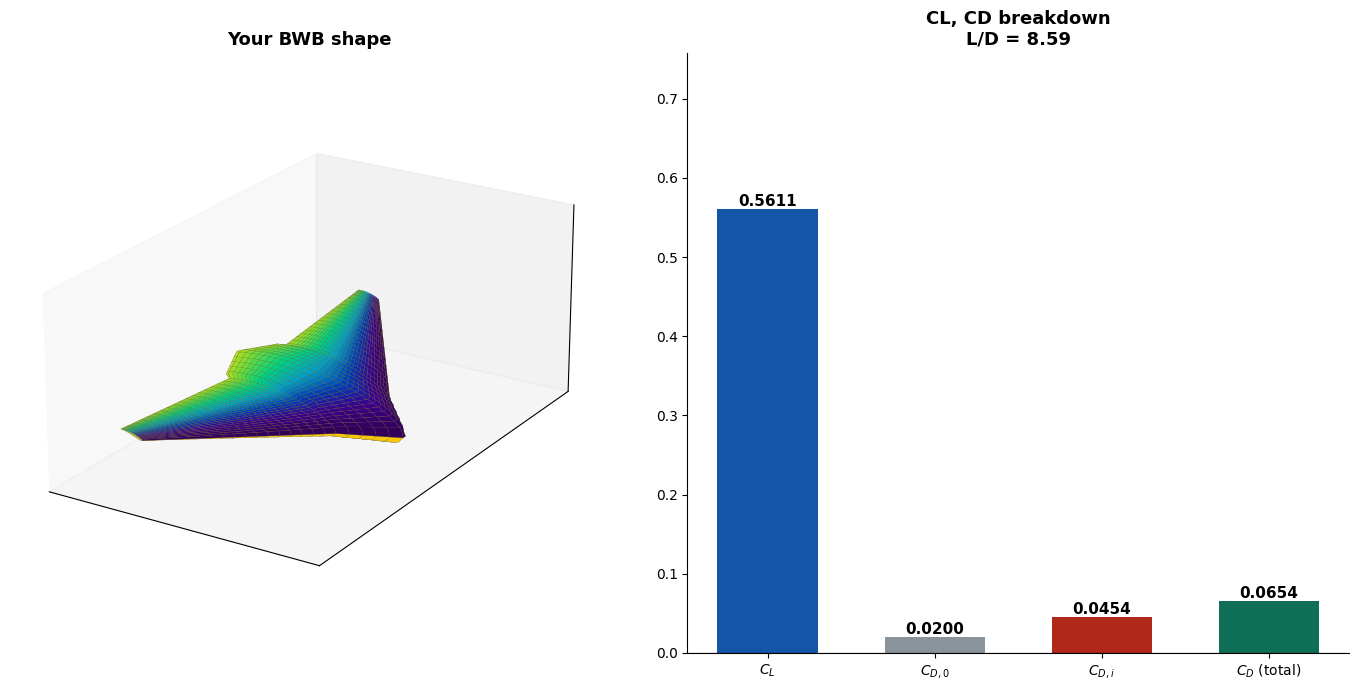

In [7]:
"""
bwb_interactive_cl_cd_ld.py
===============================
Change ANY parameter below (via the interactive prompts) and watch
CL, CD, and L/D all update live -- computed fresh from your inputs,
never hardcoded.

WHAT YOU CAN VARY AND WHAT EACH ONE DOES:

    Camber (inner/outer)     -> changes alpha_L0 -> changes CL
    Span / chord (inner/outer) -> changes AR and S -> changes CL and CD_i
    Angle of attack (alpha)  -> changes CL directly
    Span efficiency (e)      -> changes CD_i (induced drag)
    Parasite drag (CD0)      -> changes CD directly

GOVERNING EQUATIONS:
    alpha_L0 = DEG_PER_CAMBER_UNIT * avg_camber
    AR       = (2*half_span)^2 / (2*S)
    CL       = (2*pi*AR/(AR+2)) * (alpha - alpha_L0)
    CD_i     = CL^2 / (pi * e * AR)
    CD       = CD0 + CD_i
    L/D      = CL / CD

Run:
    python3 bwb_interactive_cl_cd_ld.py

Produces:
    bwb_interactive_result.png   (3D shape + CL/CD/L-D summary panel)
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


def ask(prompt, default):
    raw = input(f"{prompt} [default {default}]: ").strip()
    return float(raw) if raw else default


# =============================================================================
# INTERACTIVE INPUT -- press Enter at any prompt to keep the default
# =============================================================================
print("=" * 70)
print("BWB PARAMETER INPUT -- change any value, CL/CD/L-D update live")
print("=" * 70)
print("\n--- Geometry (affects CL via camber, AR via span/chord) ---")
INNER_CAMBER = ask("Inner (centerbody) camber strength", 0.042)
OUTER_CAMBER = ask("Outer (wing) camber strength", 0.058)
INNER_SPAN = ask("Inner span (mm)", 22.0)
OUTER_SPAN = ask("Outer span (mm)", 70.0)
INNER_ROOT = ask("Inner root chord (mm)", 86.0)
INNER_TIP = ask("Inner tip chord (mm)", 56.0)
OUTER_ROOT = ask("Outer root chord (mm)", 56.0)
OUTER_TIP = ask("Outer tip chord (mm)", 15.0)

print("\n--- Flight condition ---")
ALPHA_DEG = ask("Angle of attack, alpha (deg)", 0.0)

print("\n--- Drag model ---")
SPAN_EFFICIENCY = ask("Span efficiency, e (typical 0.7-0.95)", 0.85)
CD0 = ask("Parasite drag coefficient, CD0", 0.014)

# fixed cosmetic-only parameters (don't affect CL/CD, only the drawn shape)
INNER_SWEEP, OUTER_SWEEP = 45.0, 35.0
INNER_THICK, OUTER_THICK = 0.18, 0.10
DEG_PER_CAMBER_UNIT = -75.0

HALF_SPAN = INNER_SPAN + OUTER_SPAN

# =============================================================================
# COMPUTE CL, CD, L/D -- all live from your inputs above
# =============================================================================
def panel_area(span, root, tip):
    return span * (root + tip) / 2.0


A_in = panel_area(INNER_SPAN, INNER_ROOT, INNER_TIP)
A_out = panel_area(OUTER_SPAN, OUTER_ROOT, OUTER_TIP)
S = A_in + A_out
AR = (2 * HALF_SPAN) ** 2 / (2 * S)

avg_camber = (A_in * INNER_CAMBER + A_out * OUTER_CAMBER) / S
alpha_L0_deg = DEG_PER_CAMBER_UNIT * avg_camber
alpha_L0_rad = np.radians(alpha_L0_deg)
alpha_rad = np.radians(ALPHA_DEG)

CL = (2 * np.pi * AR / (AR + 2)) * (alpha_rad - alpha_L0_rad)
CD_i = CL ** 2 / (np.pi * SPAN_EFFICIENCY * AR)
CD = CD0 + CD_i
LD = CL / CD if CD != 0 else float('nan')

print("\n" + "=" * 70)
print("RESULTS -- computed live from your inputs")
print("=" * 70)
print(f"Reference area S = {S:.1f} mm^2")
print(f"Aspect ratio AR  = {AR:.3f}")
print(f"Zero-lift angle alpha_L0 = {alpha_L0_deg:.3f} deg")
print(f"CL   = {CL:.4f}")
print(f"CD0  = {CD0:.4f}   (parasite drag)")
print(f"CD_i = {CD_i:.4f}   (induced drag = CL^2/(pi*e*AR))")
print(f"CD   = {CD:.4f}   (total drag)")
print(f"L/D  = {LD:.2f}")
print("=" * 70)

# =============================================================================
# BUILD THE 3D SHAPE FROM THE SAME INPUTS
# =============================================================================
def naca_thickness(xc, t):
    return 5 * t * (0.2969 * np.sqrt(xc) - 0.1260 * xc
                     - 0.3516 * xc ** 2 + 0.2843 * xc ** 3
                     - 0.1015 * xc ** 4)


def camber_supercritical(xc, k):
    return k * (xc ** 1.6) * (1 - xc) * 5.2


def local_chord(y):
    ay = np.abs(y)
    inner = INNER_ROOT - (INNER_ROOT - INNER_TIP) * np.clip(ay / INNER_SPAN, 0, 1)
    outer = OUTER_ROOT - (OUTER_ROOT - OUTER_TIP) * \
        np.clip((ay - INNER_SPAN) / OUTER_SPAN, 0, 1)
    return np.where(ay <= INNER_SPAN, inner, outer)


def leading_edge_x(y):
    ay = np.abs(y)
    le_j = INNER_SPAN * np.tan(np.radians(INNER_SWEEP))
    inner_le = ay * np.tan(np.radians(INNER_SWEEP))
    outer_le = le_j + (ay - INNER_SPAN) * np.tan(np.radians(OUTER_SWEEP))
    return np.where(ay <= INNER_SPAN, inner_le, outer_le)


def thickness_ratio(y):
    frac = np.clip(np.abs(y) / HALF_SPAN, 0, 1)
    return INNER_THICK * (1 - frac) + OUTER_THICK * frac


def camber_strength(y):
    frac = np.clip(np.abs(y) / HALF_SPAN, 0, 1)
    return INNER_CAMBER * (1 - frac) + OUTER_CAMBER * frac


def cp_upper(xc):
    return -1.2 + 1.5 * xc


def cp_lower(xc):
    return 0.5 - 0.35 * xc


_stops = [0.00, 0.15, 0.30, 0.45, 0.60, 0.75, 0.88, 1.00]
_colors = ['rgb(50,0,90)', 'rgb(60,0,140)', 'rgb(0,60,180)', 'rgb(0,160,200)',
           'rgb(0,210,130)', 'rgb(120,220,50)', 'rgb(240,220,20)',
           'rgb(255,180,0)']
_rgb = lambda s: tuple(int(n) / 255 for n in s[s.index('(') + 1:s.index(')')].split(','))
CMAP = mcolors.LinearSegmentedColormap.from_list('u', list(zip(_stops, [_rgb(c) for c in _colors])))
NORM = mcolors.Normalize(vmin=-1.2, vmax=0.6)
PITCH = np.radians(-14)


def pitch_rotate(Xp, Zp):
    return (Xp * np.cos(PITCH) + Zp * np.sin(PITCH),
            -Xp * np.sin(PITCH) + Zp * np.cos(PITCH))


n_span, n_chord = 90, 60
y_vals = np.linspace(-HALF_SPAN, HALF_SPAN, n_span)
xc_vals = np.linspace(0, 1, n_chord)
XC, Y = np.meshgrid(xc_vals, y_vals)
chord = local_chord(Y)
X = leading_edge_x(Y) + XC * chord
t_ratio = thickness_ratio(Y)
k_cam = camber_strength(Y)
half_t = naca_thickness(XC, t_ratio) * chord
camber = camber_supercritical(XC, k_cam) * chord
Zu = camber + half_t
Zl = camber - half_t
Xu, Zu = pitch_rotate(X, Zu)
Xl, Zl = pitch_rotate(X, Zl)

# =============================================================================
# FIGURE -- 3D shape + a CL/CD/L-D summary bar panel side by side
# =============================================================================
fig = plt.figure(figsize=(14, 7))
ax3d = fig.add_subplot(1, 2, 1, projection='3d')
ax3d.plot_surface(Xu, Y, Zu, facecolors=CMAP(NORM(cp_upper(XC))),
                    linewidth=0.1, edgecolor='0.3', antialiased=True, shade=False)
ax3d.plot_surface(Xl, Y, Zl, facecolors=CMAP(NORM(cp_lower(XC))),
                    linewidth=0.1, edgecolor='0.3', antialiased=True, shade=False)
ax3d.set_xlim(-20, 100)
ax3d.set_ylim(-HALF_SPAN - 10, HALF_SPAN + 10)
ax3d.set_zlim(-10, 70)
ax3d.set_box_aspect((12, 19, 8))
ax3d.set_xticks([]); ax3d.set_yticks([]); ax3d.set_zticks([])
ax3d.set_title('Your BWB shape', fontsize=13, weight='bold')
ax3d.view_init(elev=22, azim=-58)
ax3d.invert_xaxis()

ax_bar = fig.add_subplot(1, 2, 2)
labels = ['$C_L$', '$C_{D,0}$', '$C_{D,i}$', '$C_D$ (total)']
values = [CL, CD0, CD_i, CD]
colors = ['#1355A6', '#8A929B', '#B0281A', '#0F6E56']
bars = ax_bar.bar(labels, values, color=colors, width=0.6)
ax_bar.bar_label(bars, fmt='%.4f', fontsize=11, weight='bold')
ax_bar.set_title(f'CL, CD breakdown\nL/D = {LD:.2f}', fontsize=13,
                   weight='bold')
ax_bar.axhline(0, color='black', linewidth=0.8)
ax_bar.spines[['top', 'right']].set_visible(False)
ax_bar.set_ylim(0, max(values) * 1.35)

plt.tight_layout()
plt.savefig('bwb_interactive_result.png', dpi=160, facecolor='white',
            bbox_inches='tight')
print("\nSaved: bwb_interactive_result.png")